# Grocery Checkout Simulation

###  Bus 36109 "Advanced Decision Modeling with Python", Don Eisenstein
Don Eisenstein &copy; Copyright 2022, University of Chicago 

---

Customers enter the checkout process.

- A unit of time is 1 second
- The number of items is randomly distributed Uniform(`ITEMS_LOW`, `ITEMS_HIGH`) 
- The time to checkout is `CHECKOUT_TIME_FIXED` + num_items * `CHECKOUT_TIME_PER_ITEM`
- There are `NUM_CHECKOUTS` total checkout lanes to be divided between express and full. 
- `NUM_EXPRESS_CHECKOUTS` + `NUM_FULL_CHECKOUTS` = `NUM_CHECKOUTS`
- Customer's with less than `EXPRESS_CHECKOUT_CUTOFF_ITEMS` items must use one of the express lanes 
- Customer interarrival time is Exponentially distributed with mean `MEAN_TIME_BETWEEN_ARRIVALS` 
- We simulate for `SIM_LENGTH` time units

Simplifying assumption:
- We assume that customers "jockey", move easily from one checkout queue to another, so that there is never a queue at say one Full lane while another one is empty.  So we model all the Full lanes sharing a single Full queue, and all Express lanes sharing a single Express queue.


In [1]:
import numpy as np
import simpy
from simpy_helpers import Entity, Resource, Source, Stats

In [2]:
EXPRESS_CHECKOUT_CUTOFF_ITEMS = 15
ITEMS_LOW = 1
ITEMS_HIGH = 30 
CHECKOUT_TIME_FIXED = 40
CHECKOUT_TIME_PER_ITEM = 4 
MEAN_TIME_BETWEEN_ARRIVALS = 20 # seconds
SIM_LENGTH = 10800     # seconds, equals 3 hours

NUM_CHECKOUTS = 6
NUM_EXPRESS_CHECKOUTS = 2
NUM_FULL_CHECKOUTS = NUM_CHECKOUTS - NUM_EXPRESS_CHECKOUTS 

**Note:** Per Little's law, we expect that the Average Queue Time will be the same with or without jockey-ing.

### SimPy Code

In [3]:
class GenerateShoppers(Source):

    def interarrival_time(self):
        return np.random.exponential(MEAN_TIME_BETWEEN_ARRIVALS) # seconds

    def build_entity(self):
        attributes = {}
        attributes['num_items'] = np.random.randint(ITEMS_LOW, ITEMS_HIGH+1)

        if attributes['num_items'] < EXPRESS_CHECKOUT_CUTOFF_ITEMS:
            attributes['checkout_type'] = 'express'
        else:
            attributes['checkout_type'] = 'full'

        return Shopper(env, attributes)

In [4]:
class Shopper(Entity):

    def process(self):
        if self.attributes['checkout_type'] == 'express':
            yield self.wait_for_resource(express)
            yield self.process_at_resource(express)
            self.release_resource(express)
        else:
            yield self.wait_for_resource(full)
            yield self.process_at_resource(full)
            self.release_resource(full)

In [5]:
class Express(Resource):

    def service_time(self, entity):
        num_items = entity.attributes['num_items']
        checkout_time = CHECKOUT_TIME_FIXED + num_items * CHECKOUT_TIME_PER_ITEM
        return checkout_time


class Full(Resource):

    def service_time(self, entity):
        num_items = entity.attributes['num_items']
        checkout_time = CHECKOUT_TIME_FIXED + num_items * CHECKOUT_TIME_PER_ITEM
        return checkout_time

In [6]:
np.random.seed(429)
env = simpy.Environment()
express = Express(env, capacity=NUM_EXPRESS_CHECKOUTS)
full = Full(env, capacity=NUM_FULL_CHECKOUTS)

source = GenerateShoppers(env)
env.process(source.start(debug=False))
env.run(until=SIM_LENGTH)

In [7]:
print("STATISTICS \n")

# Average waiting time for all
waiting_times = Stats.get_waiting_times()
average_waiting_time = round(np.mean(waiting_times), 2)
print(f'Average customer waits for {average_waiting_time} seconds')

# Average processing time for all
processing_times = Stats.get_processing_times()
average_processing_time = round(np.mean(processing_times), 2)
print(f'Average processing time is {average_processing_time} seconds')

print("\n EXPRESS CUSTOMERS \n")
    
# Average wait time for express shoppers
waiting_times_express = Stats.get_waiting_times(express)
# Alternative: waiting_times_express = Stats.get_waiting_times(attributes={'checkout_type': 'express'})
average_waiting_time_express = round(np.mean(waiting_times_express), 2)
print(f'   Average customer waits for {average_waiting_time_express} seconds')

# Average processing time for express shoppers
print(f'   Average processing time is {round(np.mean(Stats.get_processing_times(express)))} seconds')

# Average queue size for express shoppers
print(f'   Average queue size is {round(np.mean(Stats.queue_size_over_time(express)),2)}')

print("\n FULL CUSTOMERS \n")

# Average wait time for full shoppers
print(f'   Average waiting time is {round(np.mean(Stats.get_waiting_times(full)),2)} seconds')

# Average processing time for full shoppers
print(f'   Average processing time is {round(np.mean(Stats.get_processing_times(full)),2)} seconds')

# Average queue size for full shoppers
print(f'   Average queue size is {round(np.mean(Stats.queue_size_over_time(full)),2)}')

STATISTICS 

Average customer waits for 139.7 seconds
Average processing time is 102.79 seconds

 EXPRESS CUSTOMERS 

   Average customer waits for 72.54 seconds
   Average processing time is 68 seconds
   Average queue size is 1.59

 FULL CUSTOMERS 

   Average waiting time is 193.43 seconds
   Average processing time is 130.6 seconds
   Average queue size is 5.28


In [8]:
import matplotlib.pyplot as plt

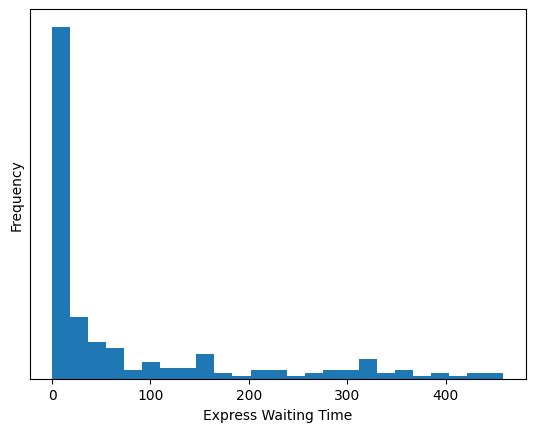

In [9]:
"""
Histogram of Express  Waiting time in system 
"""

system_time = Stats.get_waiting_times(express)
plt.hist(system_time,bins=25)
# you can customize the exact tick marks on an axis
# Turn off y tick numbrers 
plt.yticks([])
plt.ylabel('Frequency');
plt.xlabel('Express Waiting Time');
plt.show()

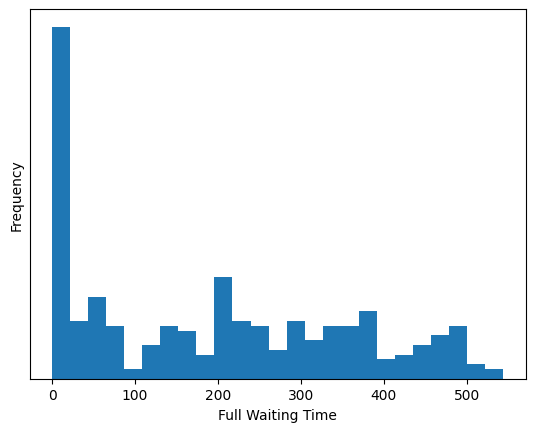

In [10]:
"""
Histogram of Full  Waiting time in system 
"""

system_time = Stats.get_waiting_times(full)
plt.hist(system_time,bins=25)
# you can customize the exact tick marks on an axis
# Turn off y tick numbrers 
plt.yticks([])
plt.ylabel('Frequency');
plt.xlabel('Full Waiting Time');
plt.show()

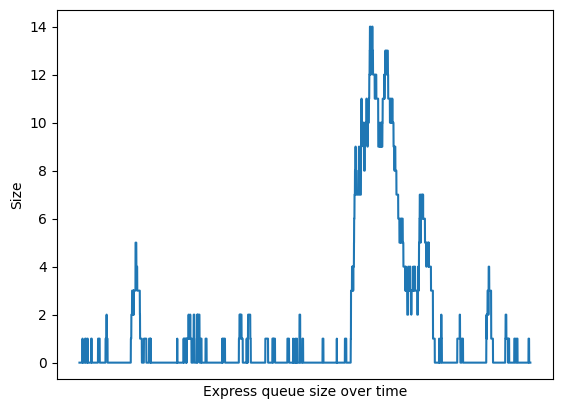

In [11]:
"""
Express Queue size over time
"""
queue = Stats.queue_size_over_time(express)
plt.plot(queue)
plt.ylabel('Size');
plt.xlabel('Express queue size over time');
# Turn off x tick numbrers 
plt.xticks([])
plt.show()

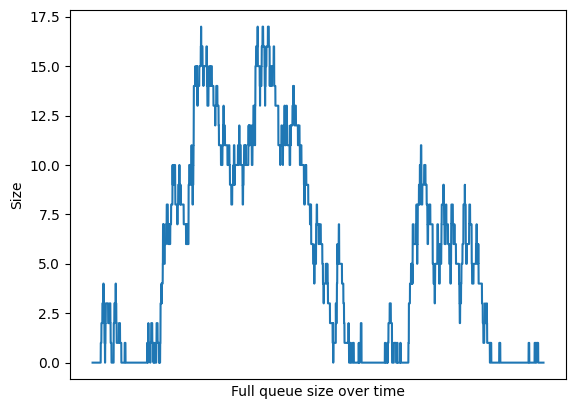

In [12]:
"""
Full Queue size over time
"""
queue = Stats.queue_size_over_time(full)
plt.plot(queue)
plt.ylabel('Size');
plt.xlabel('Full queue size over time');
# Turn off x tick numbrers 
plt.xticks([])
plt.show()

### Iterate and rerun simulation over `NUM_FULL_CHECKOUTS`

--------------------------------------------------
Num FULL Checkouts: 1
Num EXPRESS Checkouts: 5


STATISTICS 

 EXPRESS CUSTOMERS
   Average customer waits for 0.36 seconds
   Average queue size is 0.01
 FULL CUSTOMERS
   Average waiting time is 4145.83 seconds
   Average queue size is 107.38
--------------------------------------------------
Num FULL Checkouts: 2
Num EXPRESS Checkouts: 4


STATISTICS 

 EXPRESS CUSTOMERS
   Average customer waits for 0.93 seconds
   Average queue size is 0.02
 FULL CUSTOMERS
   Average waiting time is 1759.5 seconds
   Average queue size is 41.81
--------------------------------------------------
Num FULL Checkouts: 3
Num EXPRESS Checkouts: 3


STATISTICS 

 EXPRESS CUSTOMERS
   Average customer waits for 3.98 seconds
   Average queue size is 0.08
 FULL CUSTOMERS
   Average waiting time is 531.78 seconds
   Average queue size is 12.97
--------------------------------------------------
Num FULL Checkouts: 4
Num EXPRESS Checkouts: 2


STATISTICS 

 EX

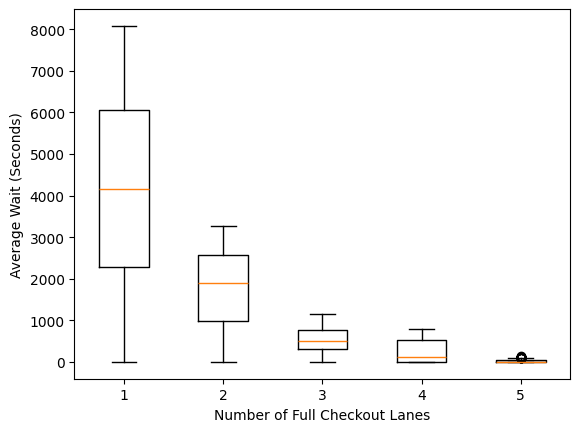

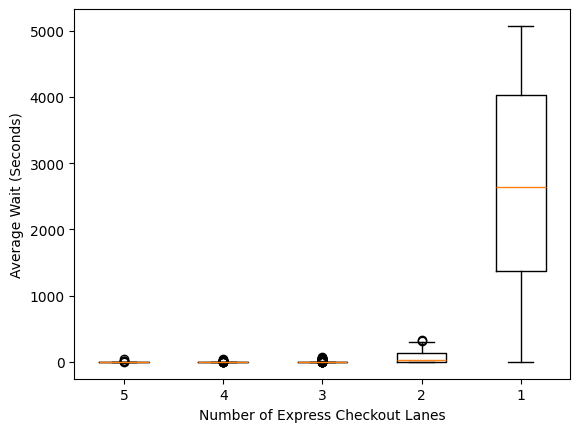

In [13]:
np.random.seed(89)

full_plot_points = []
full_avg_wait_times = []

express_plot_points = []
express_avg_wait_times = []

for num_full_checkouts in range(1, NUM_CHECKOUTS):
    num_express_checkouts = NUM_CHECKOUTS - num_full_checkouts
    print("--------------------------------------------------")
    print(f"Num FULL Checkouts: {num_full_checkouts}")
    print(f"Num EXPRESS Checkouts: {num_express_checkouts}")

    # Run simulation

    env = simpy.Environment()
    express = Express(env, capacity=num_express_checkouts)
    full = Full(env, capacity=num_full_checkouts)

    source = GenerateShoppers(env)
    env.process(source.start(debug=False))
    env.run(until=SIM_LENGTH)

    print("\n")
    print("STATISTICS \n")

    print(" EXPRESS CUSTOMERS")
        
    # Average wait time for express shoppers
    waiting_times_express = Stats.get_waiting_times(express)
    average_waiting_time_express = round(np.mean(waiting_times_express), 2)
    print(f'   Average customer waits for {average_waiting_time_express} seconds')
    
    # Average queue size for express shoppers
    print(f'   Average queue size is {round(np.mean(Stats.queue_size_over_time(express)),2)}')
    
    print(" FULL CUSTOMERS")
    
    # Average wait time for full shoppers
    print(f'   Average waiting time is {round(np.mean(Stats.get_waiting_times(full)),2)} seconds')

    # Average queue size for full shoppers
    print(f'   Average queue size is {round(np.mean(Stats.queue_size_over_time(full)),2)}')

    # Add to list for plotting
    full_plot_points.append(num_full_checkouts)
    full_avg_wait_times.append(Stats.get_waiting_times(full))
    
    express_plot_points.append(num_express_checkouts)
    express_avg_wait_times.append(Stats.get_waiting_times(express))

print("--------------------------------------------------")

plt.boxplot(full_avg_wait_times)
plt.xticks(full_plot_points)
plt.xlabel("Number of Full Checkout Lanes")
plt.ylabel("Average Wait (Seconds)")
plt.show()

plt.boxplot(express_avg_wait_times)
plt.xticks(express_plot_points)
plt.xlabel("Number of Express Checkout Lanes")
plt.ylabel("Average Wait (Seconds)")
plt.show()